<a href="https://colab.research.google.com/github/leticiacanton/churn-prediction-poc/blob/main/churn_prediction_desafio_A3data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Autor: Leticia Dal Canton

## Desafio Técnico: Redução de Churn - Empresa de Telecomunicações

### Definição do problema:
A empresa de telecomunicações contratou a A3Data para avaliar o cenário de churn elevado dos seus clientes e, uma vez que estamos falando de um produto com custo elevado de setup (instalação), a empresa gostaria de uma estratégia
para reduzir esse churn.

### Objetivos:
- Identificar padrões de cancelamento;
- Desenvolver um modelo estável, para uma PoC, que identifique candidatos a churn;
- Propor estratégias de retenção.

In [5]:
## Libraries

# Manipulação e DataViz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA
!pip install ydata-profiling -q
from ydata_profiling import ProfileReport

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, precision_recall_curve, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## Carregamento da base

In [6]:
df = pd.read_csv('Customer-Churn - Customer-Churn.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   gender            7043 non-null   object
 2   SeniorCitizen     7043 non-null   int64 
 3   Partner           7043 non-null   object
 4   Dependents        7043 non-null   object
 5   tenure            7043 non-null   int64 
 6   PhoneService      7043 non-null   object
 7   MultipleLines     7043 non-null   object
 8   InternetService   7043 non-null   object
 9   OnlineSecurity    7043 non-null   object
 10  OnlineBackup      7043 non-null   object
 11  DeviceProtection  7043 non-null   object
 12  TechSupport       7043 non-null   object
 13  StreamingTV       7043 non-null   object
 14  StreamingMovies   7043 non-null   object
 15  Contract          7043 non-null   object
 16  PaperlessBilling  7043 non-null   object
 17  PaymentMethod 

## Limpeza e Tratamento de Variáveis

1. 'MonthlyCharges' e 'TotalCharges' estão como string, mas são valores númericos, vamos tratar isso.
2. Verificar quais são os casos nulos em 'TotalCharges'.

In [9]:
# Tratamento de vírgulas e conversão para float
df['MonthlyCharges'] = df['MonthlyCharges'].str.replace(',', '.').astype(float)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.replace(',', '.'), errors='coerce')

In [12]:
print(df[df['TotalCharges'].isnull()]['tenure'].eq(0).all())
print(df[df['tenure'] == 0]['TotalCharges'].isnull().all())

True
True


- Como 'TotalCharges' representa o valor total cobrado do cliente até o momento, a suspeita inicial foi que 'TotalCharges' nulos são de clientes que acabaram de aderir ao serviço. Para confirmar essa hipótese, o 'tenure' também teria que ser 0, o que se confirmou.

- Esses clientes serão removidos da base. Isso se justifica pelo objetivo da análise, que é prever quem vai sair (churn), e pra isso, o usuário precisa ter tido oportunidade de sair. A análise de Churn foca em prever a ruptura de um relacionamento estabelecido, o que não é o caso de um cliente que não completou o primeiro mês de contrato.

- Isso não significa que a empresa não deva olhar para esses clientes, pelo contrário. Mas para eles, a estratégia correta não é um modelo de ML de Churn, mas sim indicadores de satisfação, por exemplo, como Onboarding e Qualidade de Instalação, que devem ser tratados em um roadmap de dados separado para não enviesar a predição de comportamento de longo prazo.


In [13]:
# Remoção de Outliers de Negócio: Clientes com Tenure 0
df = df[df['tenure'] > 0].copy()

## Diagnóstico Ágil (YData-Profiling)

Foi utilizado o Profile Report para uma varredura inicial de correlações e distribuições

In [14]:
profile = ProfileReport(df, title="Análise de Churn - Telecom", explorative=True)
profile.to_file("relatorio_detalhado_churn.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [00:02<00:00,  9.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Característica da amostra e insights rápidos

> Principais características observadas na amostra:

- Bem equilibrada entre homens e mulheres (50.5% são homens);
- Apenas 16% são idosos;
- Cerca de 48% é casado/tem parceiro;
- A maioria não tem dependentes no plano (70%);
- A maioria tem plano de telefonia (90%), dos quais 53% não tem múltiplas linhas;
- Dentre os que tem plano de internet (80%), a maioria é fibra optica (56%), não tem serviço de segurança online adicional(63%), nem backup (56%), não tem plano proteção do dispositivo (56%) e nem suporte técnico (63%);
- Cerca de metade dos usuários com plano de internet tbm contratam streaming de TV ou filmes;
- 55% dos usuários optam pela contratação mensal do plano;
- Cerca de 60% adere ao envio digital da fatura;
- O formato de pagamento mais comum é o Electronic check, algo como um boleto (34%).

> Histogramas com tempo de contrato, valor pago mensalmente e total cobrado até o momento:

- 25% da amostra tem até 9 meses de contrato;
- 25% paga até 35.58 por mês;
- Sobre o total faturado por cliente no período de contrato, temos uma mediana (1397.47) bem distante da média (2283.30). A média é provavelmente "puxada" para cima por um grupo pequeno de clientes muito antigos e de alto valor. A realidade do cliente "do meio" (mediana) é muito mais modesta em termos financeiros. Além disso, 25% da base acumulou apenas até $401.45 em toda a sua vida útil com a empresa, como o custo de setup é elevado, temos um alerta de que um quarto da base de clientes pode ser composta por contratos que dão prejuízo;
- A taxa de churn é de 26%, aproximadamente.

## EDA direcionada para Churn

### Proporção de Churn por Faixa de Tenure

Churn,No,Yes
tenure_group,,
0-1 ano,0.523218,0.476782
1-2 anos,0.712891,0.287109
2-4 anos,0.796110,0.203890
4+ anos,0.904868,0.095132


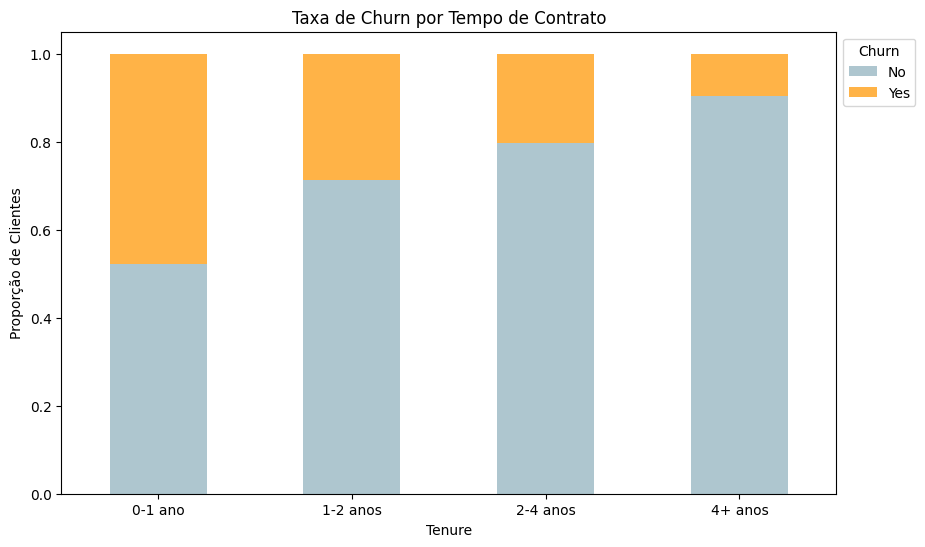

In [24]:
palette_churn = {'Yes': '#FFB347', 'No': '#AEC6CF'} # manter a mesma paleta de cores nos gráficos

# Criação de faixas de tenure para melhor visualização
def agrupar_tenure(t):
    if t <= 12: return '0-1 ano'
    elif t <= 24: return '1-2 anos'
    elif t <= 48: return '2-4 anos'
    else: return '4+ anos'

df['tenure_group'] = df['tenure'].apply(agrupar_tenure)

# Gráfico: Proporção de Churn por Faixa de Tenure
tenure_churn_prop = pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')
tenure_churn_prop = tenure_churn_prop.reindex(['0-1 ano', '1-2 anos', '2-4 anos', '4+ anos'])
display(tenure_churn_prop)

tenure_churn_prop.plot(kind='bar', stacked=True, color=palette_churn, figsize=(10, 6))
plt.title('Taxa de Churn por Tempo de Contrato')
plt.ylabel('Proporção de Clientes')
plt.xlabel('Tenure')
plt.legend(title='Churn', bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

> Taxa de Churn por Tempo de Contrato

- 47.6% de todo churn ocorre no primeiro ano de contrato. Essa porcentagem vai caindo conforme o relacionamento com a empresa fica mais duradouro. Apenas 9.5% dos clientes com contratos superiores a 4 anos cancelam;
- Logo, a chance de um cliente novo sair é quase 5 vezes maior que um cliente antigo. Isso preocupa bastante dado custo de setup.

### Mensalidade vs Churn

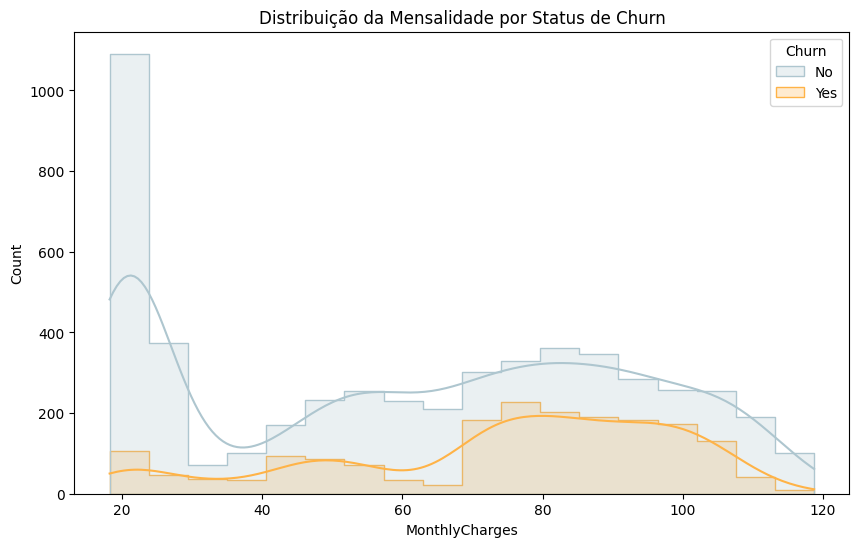

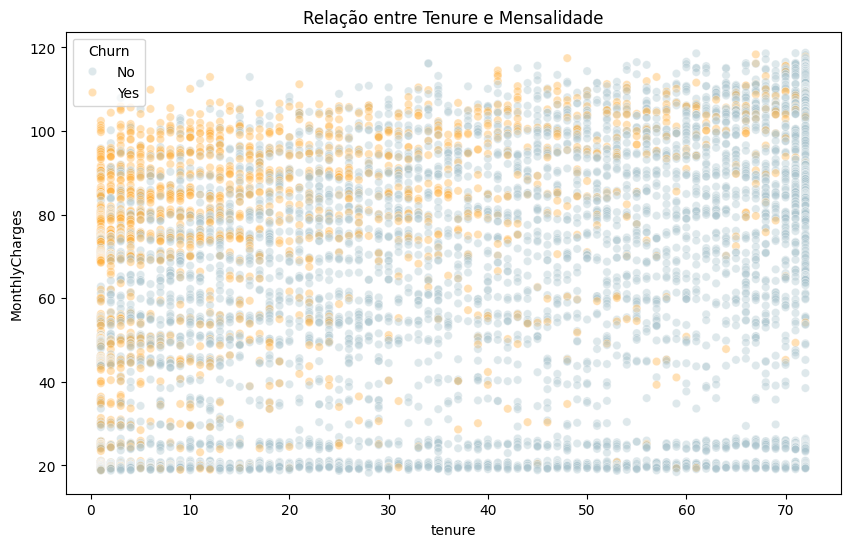

In [16]:
# Gráfico de Histograma: Mensalidade vs Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, element='step', palette=palette_churn)
plt.title('Distribuição da Mensalidade por Status de Churn')
plt.show()

# Gráfico de Dispersão: Relação Tenure vs Mensalidade
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.4, palette=palette_churn)
plt.title('Relação entre Tenure e Mensalidade')
plt.show()

### Churn por Faixas de Mensalidade

- As faixas foram obtidas após rodada de conversas de entendimento do negócio com o cliente.

In [17]:
# Análise de Churn por Faixas de Mensalidade (Monthly Charges)

# 1. Definição das Faixas
bins = [0, 30, 70, 100, 130]
labels = ['Econômico (até 30)', 'Standard (30-70)', 'Premium (70-100)', 'Ultra (100+)']
df['monthly_bracket'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels)

# 2. Cálculo da Proporção
churn_by_bracket = pd.crosstab(df['monthly_bracket'], df['Churn'], normalize='index') * 100
display(churn_by_bracket)

Churn,No,Yes
monthly_bracket,,
Econômico (até 30),90.163934,9.836066
Standard (30-70),75.609756,24.390244
Premium (70-100),62.150056,37.849944
Ultra (100+),71.951220,28.048780


> Mensalidade x Churn

- A maior taxa de churn está em planos mais caros, especialmente maiores que 70$ mensais.

### Receita Acumulada vs Churn

/tmp/ipykernel_891/4277776884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y='TotalCharges', palette=palette_churn)


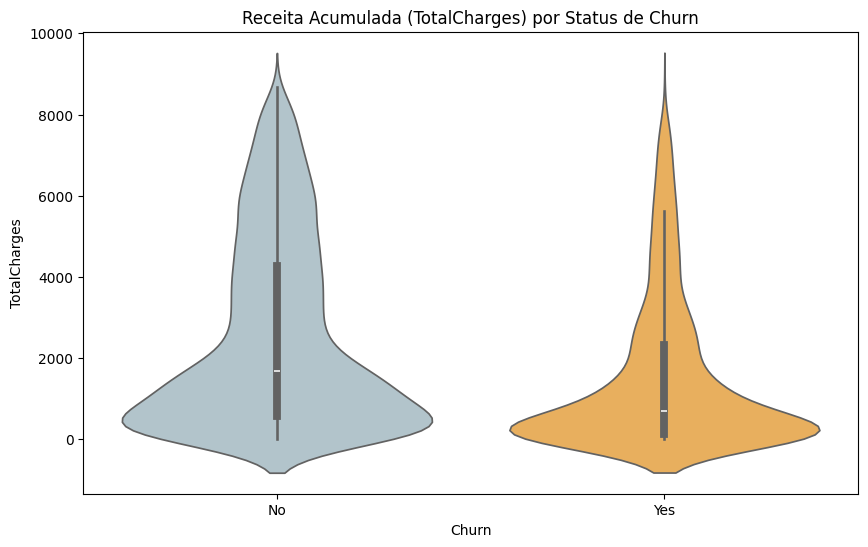

In [18]:
# Gráfico Violino
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Churn', y='TotalCharges', palette=palette_churn)
plt.title('Receita Acumulada (TotalCharges) por Status de Churn')
plt.show()

> Churn x Receita Acumulada

- Nos clientes que deram churn, o topo fino contrasta com o corpo volumoso na base: a maioria dos cancelamentos ocorre antes mesmo de o cliente gerar uma certa receita acumulada, isso corrobora com o fato já levantado da maior taxa de churn ser no primeiro ano de contrato. Isso somado ao setup alto, é um enorme ponto de alerta.


## Feature Engineering e Encoding

As variáveis foram tratadas de modo diferente para melhor desempenho do modelo:
- **Binários:** One-Hot Encoding com `drop_first=True` (evita redundância).
- **Multinível:** One-Hot Encoding preservando categorias (ex: tipos de internet) para capturar nuances de comportamento.

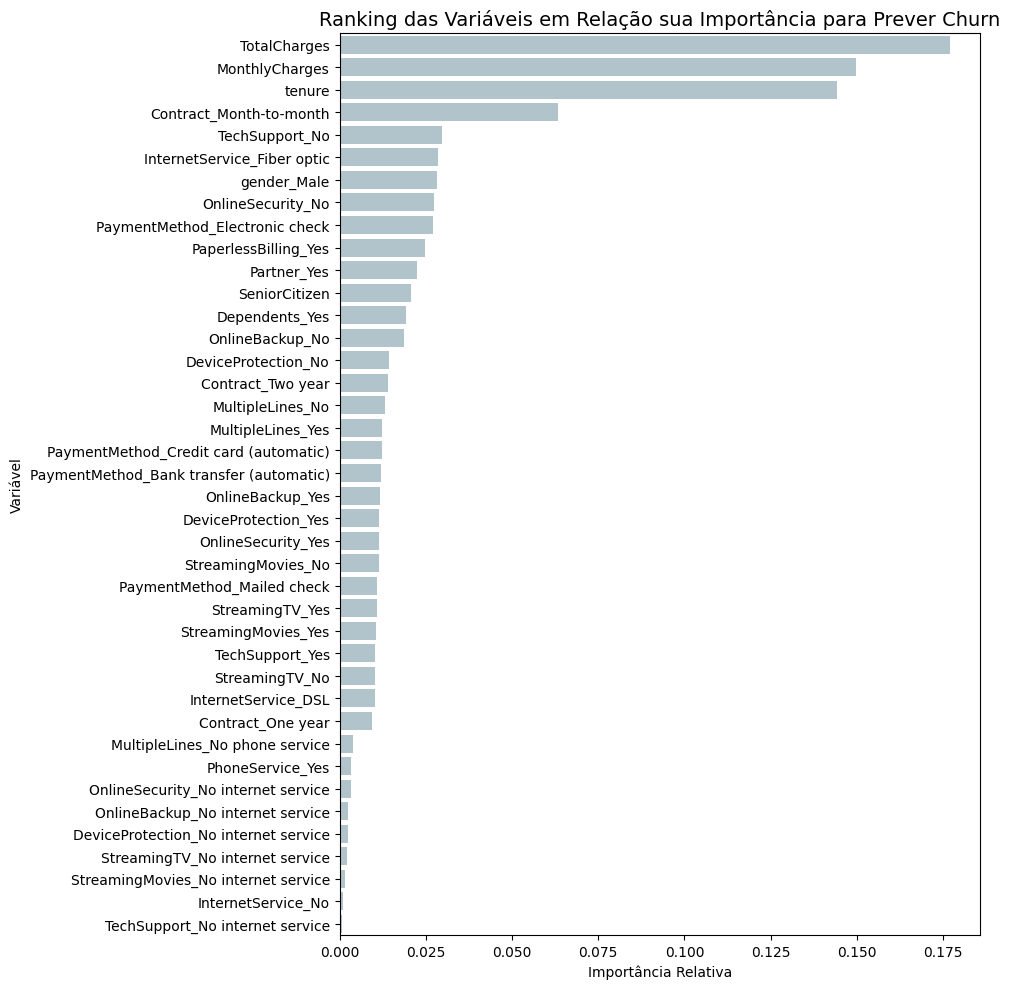

In [26]:
# 1. Preparação Final dos Dados
# Removemos colunas de ID e as auxiliares criadas apenas para a Análise Exploratória (EDA)
df_model = df.drop(columns=['customerID', 'tenure_group', 'monthly_bracket'])

# 2. Transformação de Variáveis (Encoding Inteligente e Automatizado)
# Identificamos as colunas categóricas (object)
cat_cols = df_model.select_dtypes(include=['object']).columns.drop('Churn')

# Separamos automaticamente: 2 categorias (Binária) vs +2 categorias (Multi)
cols_binarias = [col for col in cat_cols if df_model[col].nunique() == 2]
cols_multi = [col for col in cat_cols if df_model[col].nunique() > 2]

# Aplicamos o Encoding diferenciado
# drop_first=True para binárias (evita redundância: se não é Homem, é Mulher)
df_bin = pd.get_dummies(df_model[cols_binarias], drop_first=True)

# drop_first=False para multi (mantém todas as categorias para clareza no gráfico de importância)
df_multi = pd.get_dummies(df_model[cols_multi], drop_first=False)

# Capturamos as colunas numéricas automaticamente
cols_numericas = df_model.select_dtypes(exclude=['object']).columns

# Unimos tudo no X final
X = pd.concat([df_model[cols_numericas], df_bin, df_multi], axis=1)
y = df_model['Churn'].map({'Yes': 1, 'No': 0})

# 3. Treinamento do Modelo para Extração de Importância
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# 4. Cálculo da Importância
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# 5. Visualização
plt.figure(figsize=(10, 10))
sns.barplot(data=feature_importance, x='importance', y='feature', color='#AEC6CF')
plt.title('Ranking das Variáveis em Relação sua Importância para Prever Churn', fontsize=14)
plt.xlabel('Importância Relativa')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

> Por que separar em variáveis binárias e multi? Por que não aplicar o get_dummies direto?

- Para variáveis estritamente binárias (como Gender ou Partner), aplicamos o drop_first=True. Isso evita a redundância perfeita entre colunas (se é Homem, não é Mulher), reduzindo a dimensionalidade do modelo e prevenindo a Multicolinearidade, o que torna o aprendizado do algoritmo mais estável e eficiente.

- Para variáveis com 3 ou mais categorias (como Contract ou InternetService), optamos por manter todas as colunas. Isto porque, em serviços de telecom, categorias como 'Sem serviço de internet' representam perfis de consumo e riscos de churn completamente diferentes de um 'Não' simples. Manter essa distinção permite que o modelo capture nuances de comportamento entre diferentes pacotes de produtos.

## Calculando a Importância das Variáveis

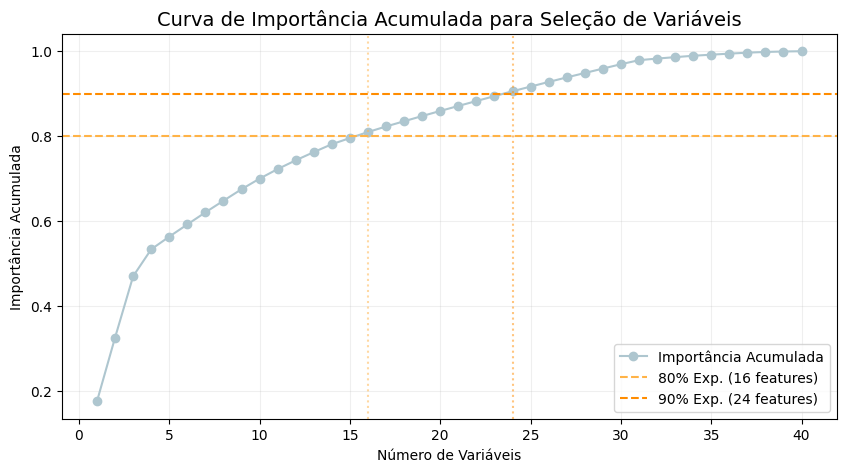

--- Comparação de Thresholds ---
Para 80% de explicabilidade: 16 variáveis.
Para 90% de explicabilidade: 24 variáveis.

Variáveis selecionadas (80%): ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract_Month-to-month', 'TechSupport_No', 'InternetService_Fiber optic', 'gender_Male', 'OnlineSecurity_No', 'PaymentMethod_Electronic check', 'PaperlessBilling_Yes', 'Partner_Yes', 'SeniorCitizen', 'Dependents_Yes', 'OnlineBackup_No', 'DeviceProtection_No', 'Contract_Two year']

Variáveis selecionadas (90%): ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract_Month-to-month', 'TechSupport_No', 'InternetService_Fiber optic', 'gender_Male', 'OnlineSecurity_No', 'PaymentMethod_Electronic check', 'PaperlessBilling_Yes', 'Partner_Yes', 'SeniorCitizen', 'Dependents_Yes', 'OnlineBackup_No', 'DeviceProtection_No', 'Contract_Two year', 'MultipleLines_No', 'MultipleLines_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Bank transfer (automatic)', 'OnlineBackup_Yes', 'DeviceProtection_

In [28]:
# 1. Calculando a Importância Acumulada
feature_importance = feature_importance.sort_values('importance', ascending=False)
feature_importance['importance_cum'] = feature_importance['importance'].cumsum()

# 2. Identificando os pontos de corte (Thresholds)
def get_threshold_info(df, pct):
    n_features = np.min(np.where(df['importance_cum'] >= pct)) + 1
    features_list = df['feature'].head(n_features).tolist()
    return n_features, features_list

n_80, vars_80 = get_threshold_info(feature_importance, 0.80)
n_90, vars_90 = get_threshold_info(feature_importance, 0.90)
n_60, vars_60 = get_threshold_info(feature_importance, 0.60) # possível cotovelo

# 3. Plotando a Curva de Explicabilidade
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(feature_importance) + 1), feature_importance['importance_cum'],
         marker='o', linestyle='-', color='#AEC6CF', label='Importância Acumulada')

# Adicionando as linhas de corte para 80% e 90%
plt.axhline(y=0.80, color='#FFB347', linestyle='--', label=f'80% Exp. ({n_80} features)')
plt.axvline(x=n_80, color='#FFB347', linestyle=':', alpha=0.5)

plt.axhline(y=0.90, color='#FF8C00', linestyle='--', label=f'90% Exp. ({n_90} features)')
plt.axvline(x=n_90, color='#FF8C00', linestyle=':', alpha=0.5)

plt.title('Curva de Importância Acumulada para Seleção de Variáveis', fontsize=14)
plt.xlabel('Número de Variáveis')
plt.ylabel('Importância Acumulada')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 4. Listando os resultados para conferência
print(f"--- Comparação de Thresholds ---")
print(f"Para 80% de explicabilidade: {n_80} variáveis.")
print(f"Para 90% de explicabilidade: {n_90} variáveis.")

print("\nVariáveis selecionadas (80%):", vars_80)
print("\nVariáveis selecionadas (90%):", vars_90)

> Qual o número ideal de variáveis?

Para determinar a arquitetura ideal do modelo, realizamos um teste de sensibilidade comparando três níveis de explicabilidade acumulada (60%, 80% e 90%).

- O modelo de 60% representa as seis variáveis que, juntas, explicam em torno de 60% da variabilidade do modelo ('cotovelo');

- O modelo de 80% busca entender se incluir mais 10 variáveis e, consequentemente, adicionar complexidade ao modelo, é justificado em termos de desempenho;

- O de 90% visa capturar as nuances mais sutis do comportamento do cliente;

- A escolha do modelo final será baseada no Recall, priorizando a redução de falsos negativos (clientes que saem sem que o modelo preveja), desde que o aumento na complexidade de variáveis traga um ganho marginal relevante na métrica.

## Modelagem e Seleção

Lembrete: O Churn é um evento de classe minoritária, neste caso, ocorre em 26% da base. Se for realizado uma divisão puramente aleatória, corremos o risco de não ter conjuntos de teste e treino balanceados em relação ao target (churn). Logo, é utilizada a divisão estratificada para preservar a distribuição da variável alvo em ambos os conjuntos, mitigando vieses decorrentes do desbalanceamento de classes.

In [21]:
# 1. Divisão única de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 2. Função de avaliação padronizada
def avaliar_modelo(features, nome):
    """
    Retorna métricas básicas para comparação entre os modelos
    """
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train[features], y_train)
    preds = model.predict(X_test[features])

    return {
        'Cenário': nome,
        'Qtd Variáveis': len(features),
        'Acurácia': round(accuracy_score(y_test, preds), 4),
        'Precisão': round(precision_score(y_test, preds), 4),
        'Recall (Churn)': round(recall_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4)
    }

# 3. Executando a comparação tripla
resultados = []
resultados.append(avaliar_modelo(vars_60, "Cotovelo (60%)"))
resultados.append(avaliar_modelo(vars_80, "Intermediário (80%)"))
resultados.append(avaliar_modelo(vars_90, "Robusto (90%)"))

# 4. DataFrame de comparação para análise
df_comparativo = pd.DataFrame(resultados)

print("--- Comparativo de Seleção de Atributos ---")
display(df_comparativo)

--- Benchmarking de Seleção de Atributos ---


,Cenário,Qtd Variáveis,Acurácia,Precisão,Recall (Churn),F1-Score
0,Cotovelo (60%),7,0.7697,0.5822,0.4733,0.5221
1,Intermediário (80%),16,0.7932,0.6487,0.4840,0.5544
2,Robusto (90%),24,0.7996,0.6597,0.5080,0.5740


> Considerações sobre os modelos

Os 3 modelos tem um recall baixo, mas o modelo de 60% apresenta um desempenho significativamente inferior também em relação a precisão, F1-Score e acurácia. Os modelos nos cenários 80% e 90% são um pouco melhores, mas muito próximos. Próxima etapa é analisar a curva de trade-off entre os modelos nos cenários 80% e 90%.

## Ajustes de Threshold

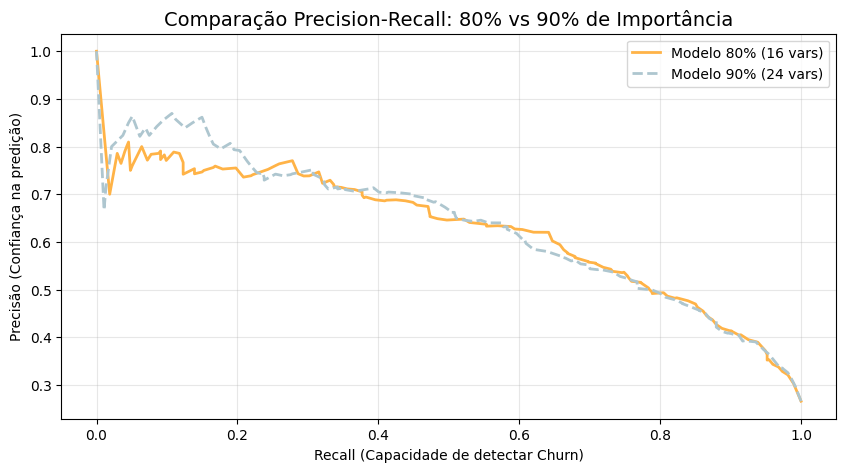

In [31]:
# 1. Preparando as probabilidades para os dois modelos
model_80 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train[vars_80], y_train)
model_90 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train[vars_90], y_train)

probs_80 = model_80.predict_proba(X_test[vars_80])[:, 1]
probs_90 = model_90.predict_proba(X_test[vars_90])[:, 1]

# 2. Calculando as curvas
prec_80, rec_80, _ = precision_recall_curve(y_test, probs_80)
prec_90, rec_90, _ = precision_recall_curve(y_test, probs_90)

# 3. Plotando a comparação
plt.figure(figsize=(10, 5))
plt.plot(rec_80, prec_80, label='Modelo 80% (16 vars)', color='#FFB347', linewidth=2)
plt.plot(rec_90, prec_90, label='Modelo 90% (24 vars)', color='#AEC6CF', linewidth=2, linestyle='--')

plt.title('Comparação Precision-Recall: 80% vs 90% de Importância', fontsize=14)
plt.xlabel('Recall (Capacidade de detectar Churn)')
plt.ylabel('Precisão (Confiança na predição)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

> Análise da Curva Precision-Recall: Validação da Parcimônia

- A sobreposição quase absoluta das curvas dos modelos de 80% (16 variáveis) e 90% (24 variáveis) é uma evidência estatística de que o incremento de atributos não resultou em ganho de poder preditivo;

- Podemos interpretar este fenômeno como uma saturação da capacidade de aprendizado do algoritmo Random Forest para este conjunto de dados específico. Portanto, a escolha do **Modelo de 80%** é ratificada, uma vez que ele entrega a mesma Área Sob a Curva (AUC-PR) do modelo mais robusto, porém com uma arquitetura mais simples e eficiente;

- Esta visualização também justifica a escolha do threshold de 0.35, pois, a partir deste ponto, é possível maximizar o Recall sem que a Precisão sofra uma queda acentuada, mantendo a viabilidade econômica das ações de retenção.

## Predição Final e Matriz de Confusão

--- PERFORMANCE FINAL DO MODELO SELECIONADO ---
Acurácia: 0.7733
Precisão: 0.5589
Recall (Churn): 0.6979
F1-Score: 0.6207
-----------------------------------------------


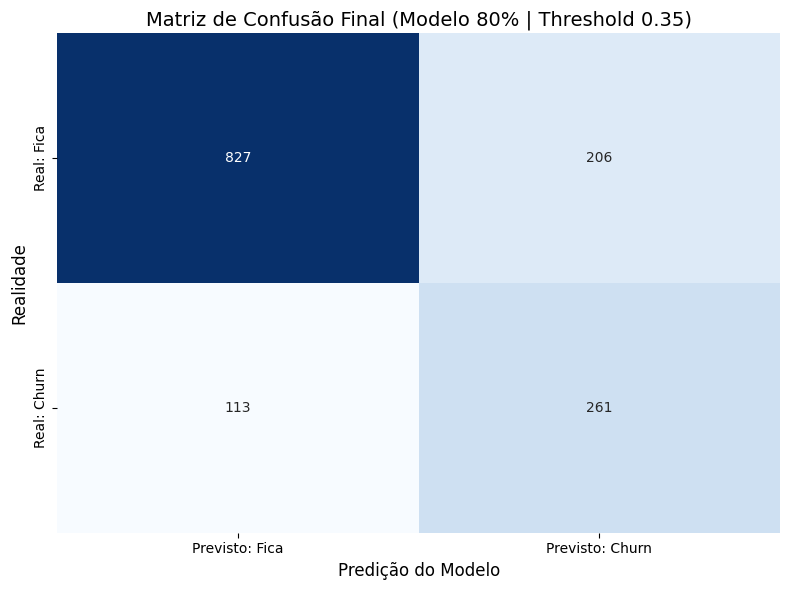

In [23]:
# 1. Gerando as predições finais com o modelo vencedor (80%) e threshold 0.35
y_pred_final = (probs_80 >= 0.35).astype(int)

# 2. Calculando as métricas
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

# 3. Exibição das métricas em formato de texto
print("--- Performance do Modelo ---")
print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {prec:.4f}")
print(f"Recall (Churn): {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 47)

# 4. Mantendo apenas o gráfico da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto: Fica', 'Previsto: Churn'],
            yticklabels=['Real: Fica', 'Real: Churn'])

plt.title('Matriz de Confusão (Modelo 80%, Threshold 0.35)', fontsize=14)
plt.ylabel('Realidade', fontsize=12)
plt.xlabel('Predição do Modelo', fontsize=12)
plt.tight_layout()
plt.show()

## Insights Finais

### Interpretação das Métricas e Estratégia de Negócio

A configuração final do modelo (16 variáveis e threshold de 0.35) foi desenhada para priorizar a **segurança da receita** da companhia.

1. **Eficiência de Detecção (Recall de 70%):** Nosso modelo identifica 7 de cada 10 clientes que pretendem cancelar. Este é o nosso principal KPI, pois permite que a equipe de retenção atue preventivamente na grande maioria dos casos críticos.

2. **Gestão do Risco de Imprecisão (Precisão de 56%):** Ao baixarmos o limiar de decisão, aceitamos um aumento controlado de Falsos Positivos (clientes que o modelo indica como risco, mas que não necessariamente cancelariam).

### Por que aumentar Falsos Positivos é mais barato que perder usuários?

No setor de Telecomunicações, existe uma clara assimetria de custos entre os erros do modelo:

* **O erro do Falso Negativo (Custo Máximo):** Ignorar um churn real significa perder o faturamento vitalício do cliente (LTV), arcar com um Custo de Aquisição (CAC) elevado para repor essa perda no mercado, além do altíssimo custo de setup relatado pelo cliente. É o erro que causaria prejuízo direto ao caixa.
* **O erro do Falso Positivo (Custo Operacional):** Enviar uma oferta de retenção para um cliente que já ia ficar tem um custo marginal baixo (ex: o valor de um upgrade de dados ou um desconto temporário). Além disso, essa ação pode funcionar como um 'mimo' que aumenta o NPS e a fidelidade deste cliente estável.

**Conclusão:** O modelo sacrifica deliberadamente uma parcela da precisão para garantir que a empresa não seja 'pega de surpresa' por cancelamentos em massa. Financeiramente, é preferível investir em retenção preventiva para alguns clientes estáveis do que perder vários clientes reais sem qualquer tentativa de negociação.

### Qual uma primeira ação a ser analisada pelo cliente?

- A análise de importância de variáveis do modelo identificou que a ausência de serviços de suporte e segurança é um dos principais fatores que elevam a probabilidade de churn;
- Foi observado também que o maior risco de churn é em clientes no primeiro ano de contrato;
- Logo, uma primeira ação poderia ser oferecer esses serviços gratuitamente ou com um desconto para clientes com adesão recente. A ideia é que serviços funcionem como uma âncora de fidelidade e impactem diretamente na taxa de churn.

### Roadmap de Evolução Técnica

Embora o Random Forest tenha apresentado um desempenho robusto e métricas de negócio acionáveis, o ciclo de vida de ciência de dados prevê iterações futuras:

1. **Testes de Algoritmos de Gradient Boosting:** A implementação de modelos como **XGBoost** ou **LightGBM** poderia reduzir ainda mais os Falsos Negativos (e os Falsos Positivos também), dado que esses algoritmos aprendem com os erros das árvores anteriores.

2. **Balanceamento de Classes:** Como o Churn representa apenas 26% da base, testar técnicas de oversampling sintético poderia ajudar o modelo a aprender melhor os padrões da classe minoritária.

3. **Feature Engineering:** Criar e adicionar ao modelo variáveis para suprir necessidades cliente (ex: ticket médio = TotalCharges/Tenure).



> Justificativa da Escolha Atual:

- Optamos por manter o Random Forest nesta etapa devido à sua alta explicabilidade e estabilidade, garantindo que as decisões de negócio propostas nesse primeiro contato com o cliente sejam baseadas em um modelo sólido, que exige poucos ajustes e trás um resultado rápido para mostrar ao novo cliente numa PoC, diferente dos algoritmos de GB que exigem um processo honeroso de ajuste e refinamento de hiperparâmetros.